--- INSIGHTS GERAIS ---
Faturamento Total com Consultas: R$ 99,780.87
Custo Total com Internações: R$ 2,943,600.00



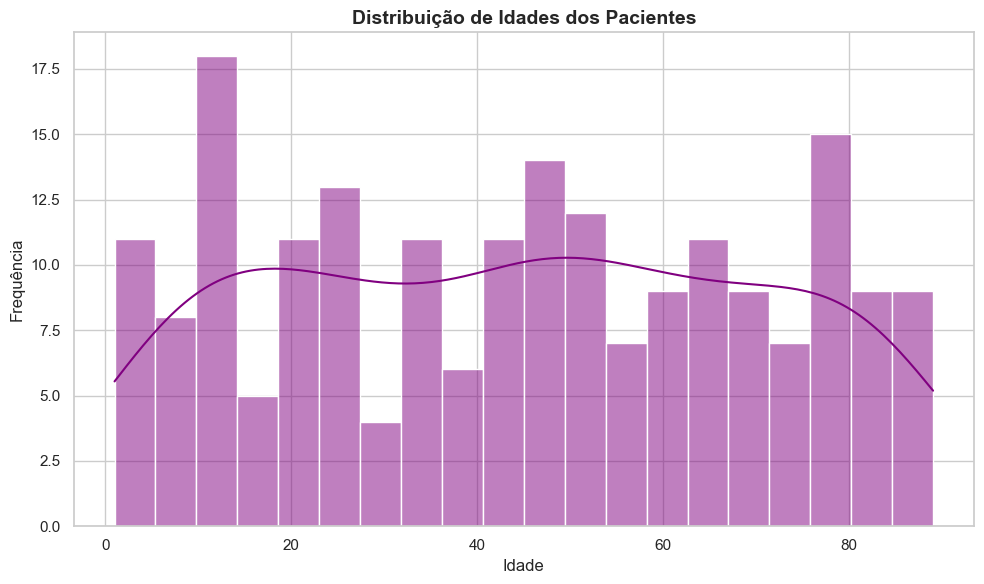

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Genero', data=df_pacientes, palette='magma')


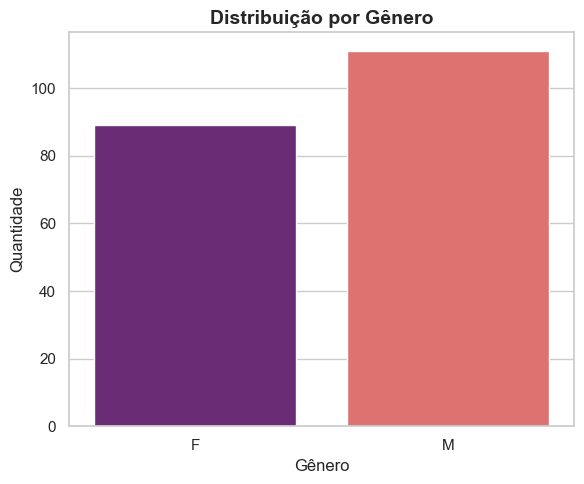

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Convenio', data=df_pacientes,


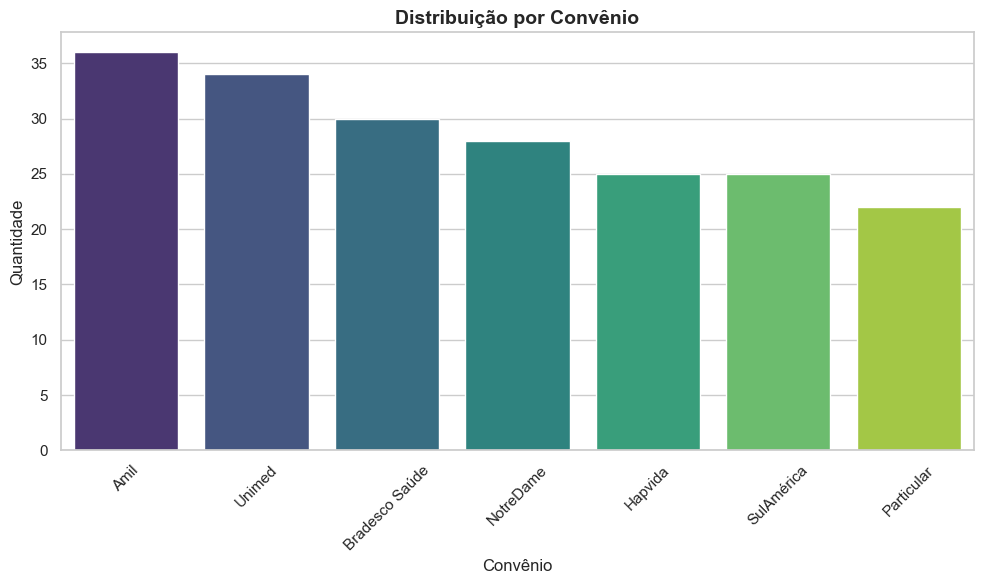

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Tipo_Sanguineo', data=df_pacientes,


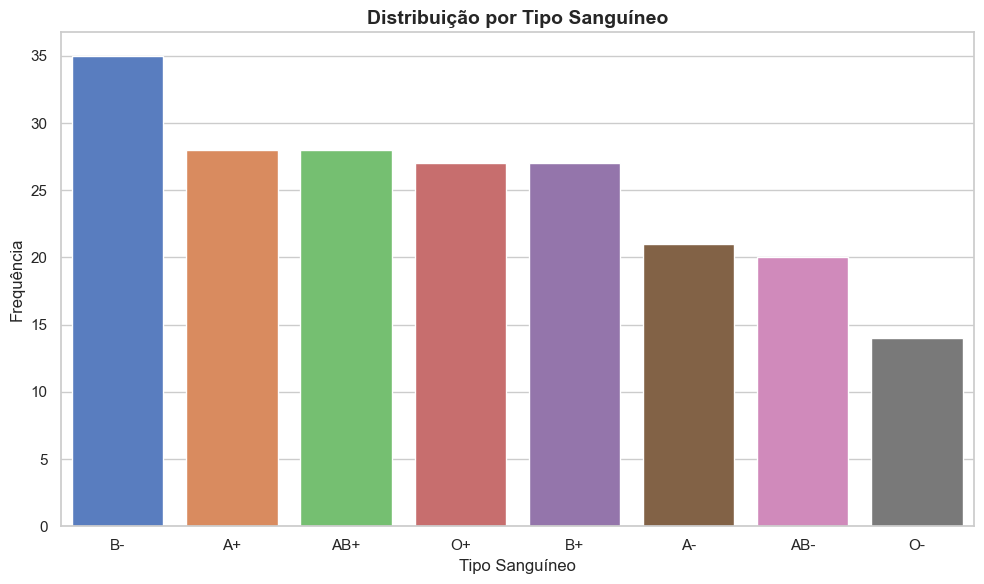

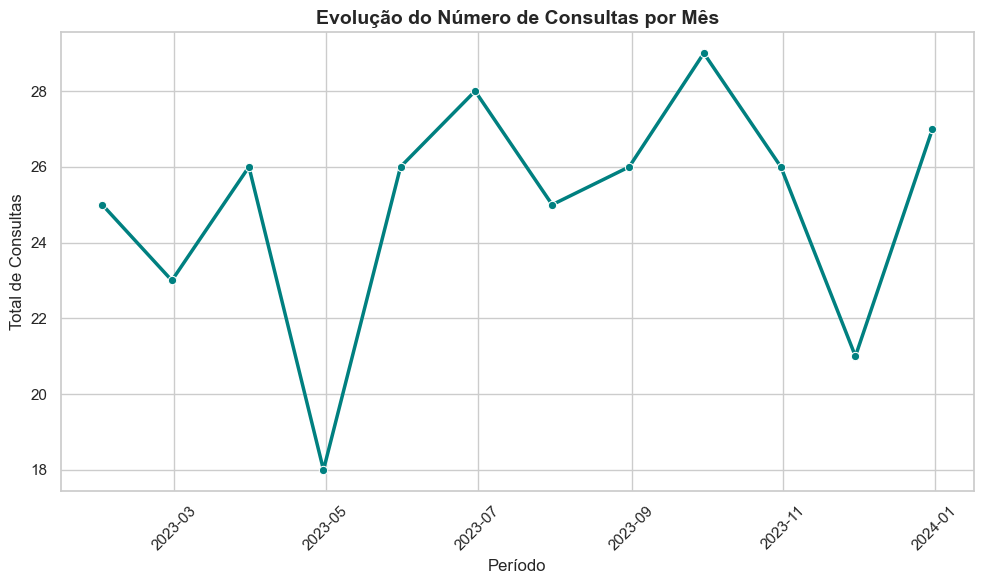

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Especialidade', data=df_consultas,


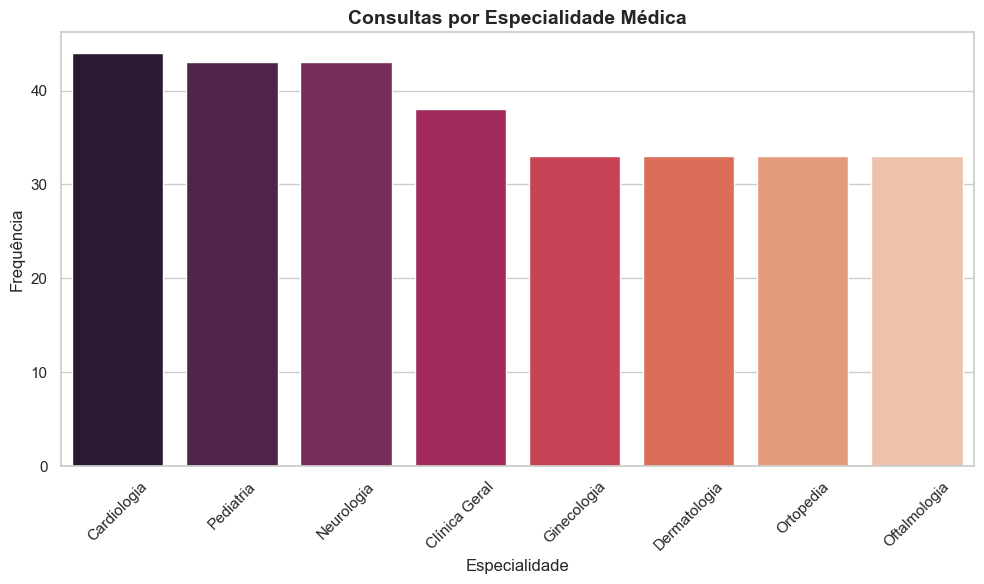

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Valor', y='Medico', data=faturamento_medicos, palette='Blues_r')


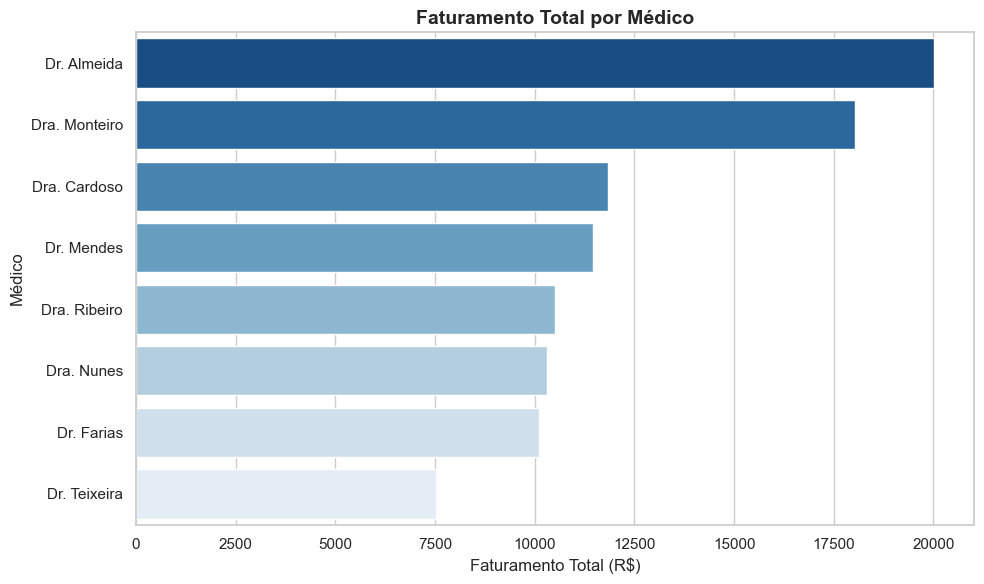

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Idade', y='Especialidade', data=idade_media_por_especialidade, palette='Blues_r')


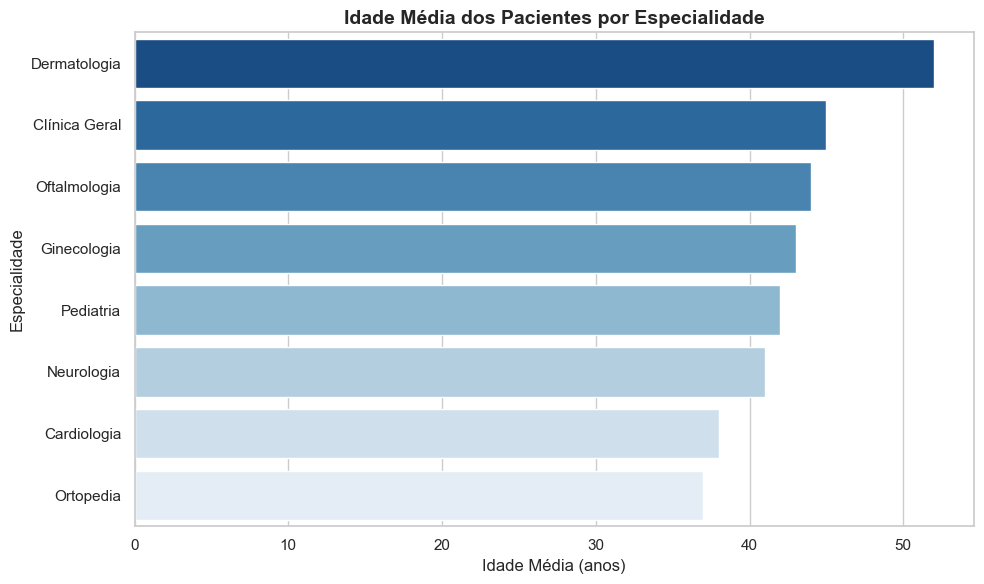

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Motivo', y='Custo_Total', data=custo_internacoes, palette='Reds_r')


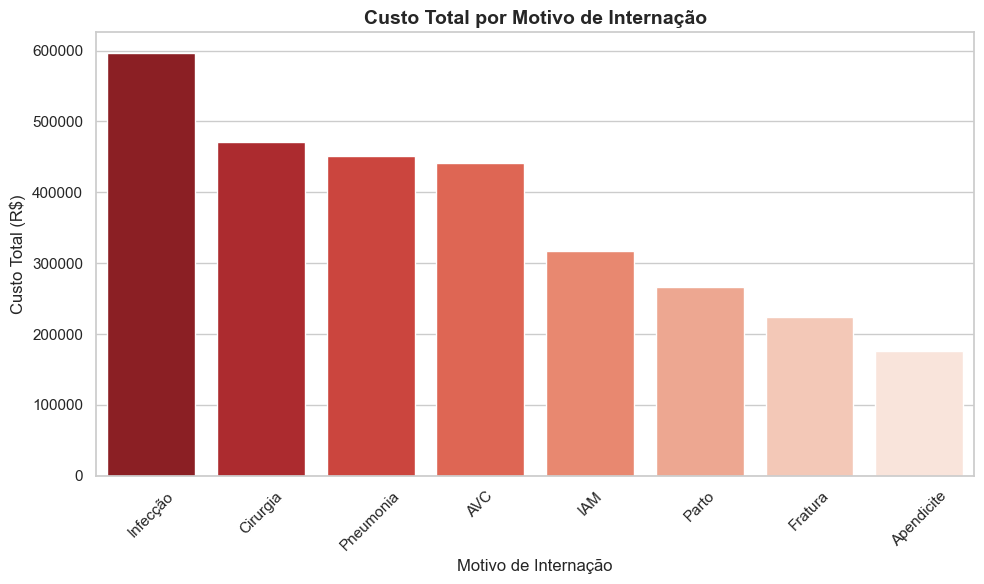

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dias_Internado', y='Motivo', data=df_internacoes,


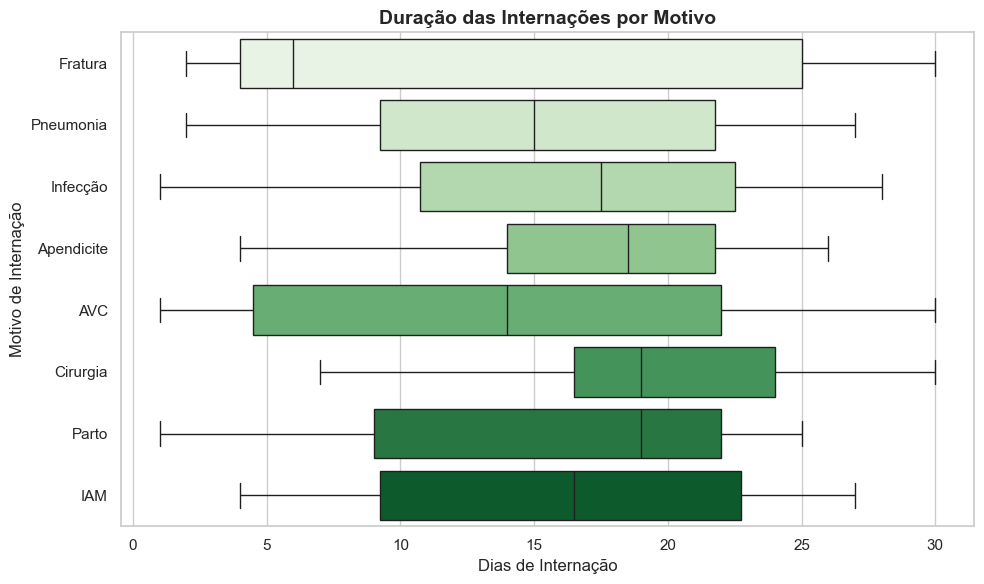

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Categoria', data=df_medicamentos,


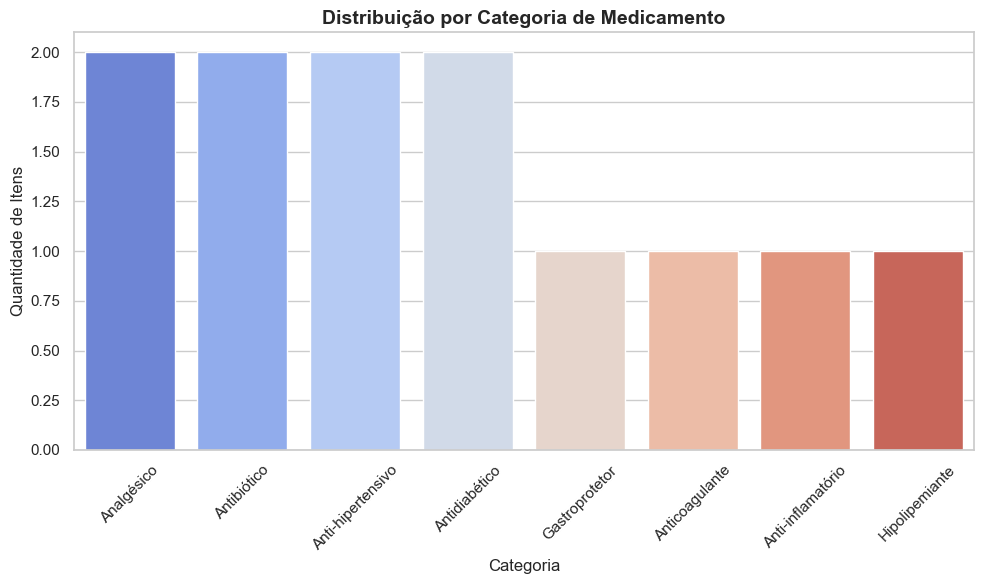

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Valor_Estoque', y='Nome', data=custo_medicamentos, palette='Purples_r')


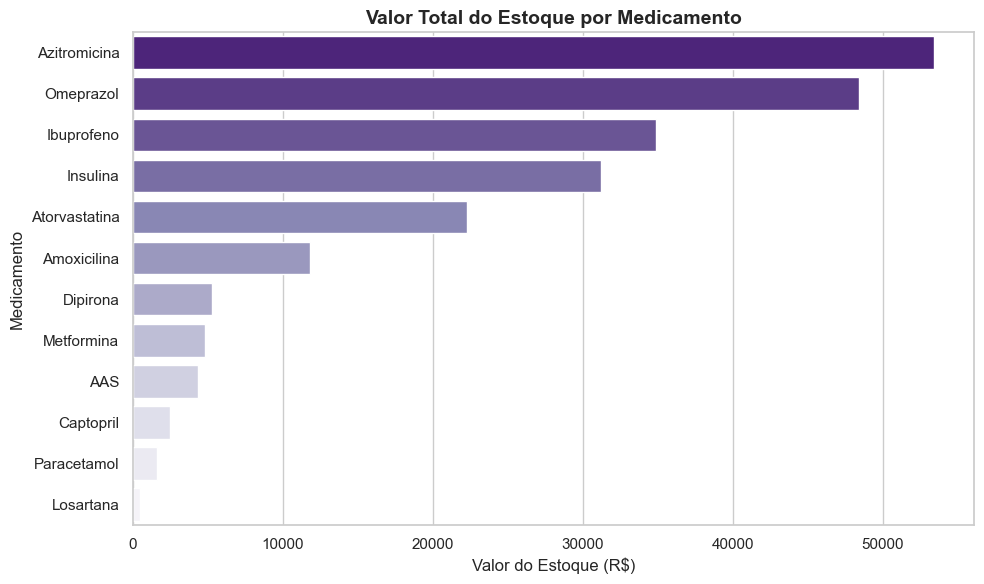

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status_Estoque', data=df_medicamentos, palette='Set1')


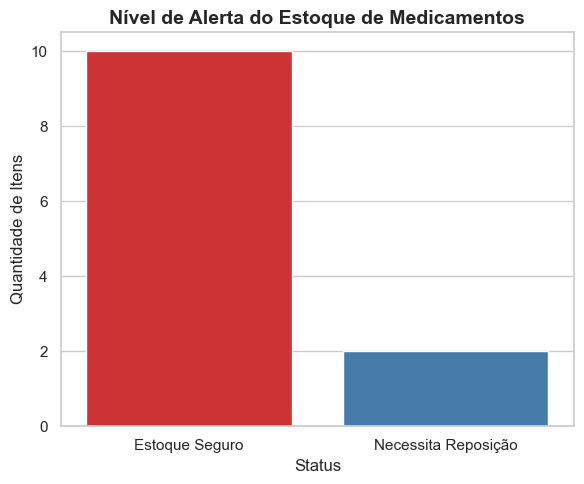

C:\Users\Ana\AppData\Local\Temp\ipykernel_16968\3841728922.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estoque_Atual', y='Nome', data=df_criticos, palette='Oranges')


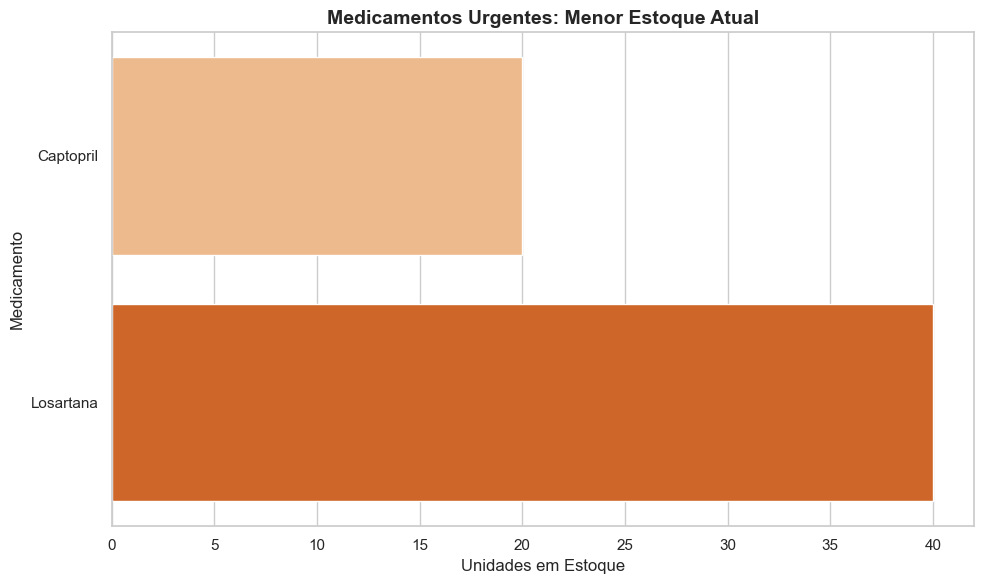

Relatório exportado com sucesso!


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


df_pacientes   = pd.read_excel('hospital_dados.xlsx', sheet_name='Pacientes')
df_consultas   = pd.read_excel('hospital_dados.xlsx', sheet_name='Consultas')
df_internacoes = pd.read_excel('hospital_dados.xlsx', sheet_name='Internacoes')
df_medicamentos = pd.read_excel('hospital_dados.xlsx', sheet_name='Medicamentos')


df_consultas['Data'] = pd.to_datetime(df_consultas['Data'])
df_internacoes['Data_Entrada'] = pd.to_datetime(df_internacoes['Data_Entrada'])

df_internacoes['Custo_Total'] = df_internacoes['Dias_Internado'] * df_internacoes['Custo_Diaria']
df_medicamentos['Valor_Estoque'] = df_medicamentos['Estoque_Atual'] * df_medicamentos['Preco_Unitario']
df_medicamentos['Status_Estoque'] = np.where(
    df_medicamentos['Estoque_Atual'] <= df_medicamentos['Estoque_Minimo'],
    'Necessita Reposição', 'Estoque Seguro'
)


print("--- INSIGHTS GERAIS ---")
print(f"Faturamento Total com Consultas: R$ {df_consultas['Valor'].sum():,.2f}")
print(f"Custo Total com Internações: R$ {df_internacoes['Custo_Total'].sum():,.2f}\n")


plt.figure()
sns.histplot(df_pacientes['Idade'], bins=20, kde=True, color='purple')
plt.title('Distribuição de Idades dos Pacientes', fontsize=14, fontweight='bold')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.countplot(x='Genero', data=df_pacientes, palette='magma')
plt.title('Distribuição por Gênero', fontsize=14, fontweight='bold')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

plt.figure()
sns.countplot(x='Convenio', data=df_pacientes,
              order=df_pacientes['Convenio'].value_counts().index, palette='viridis')
plt.title('Distribuição por Convênio', fontsize=14, fontweight='bold')
plt.xlabel('Convênio')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.countplot(x='Tipo_Sanguineo', data=df_pacientes,
              order=df_pacientes['Tipo_Sanguineo'].value_counts().index, palette='muted')
plt.title('Distribuição por Tipo Sanguíneo', fontsize=14, fontweight='bold')
plt.xlabel('Tipo Sanguíneo')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


plt.figure()
df_consultas_tempo = df_consultas.set_index('Data').resample('ME').size().reset_index(name='Total_Consultas')
sns.lineplot(x='Data', y='Total_Consultas', data=df_consultas_tempo,
             marker='o', color='teal', linewidth=2.5)
plt.title('Evolução do Número de Consultas por Mês', fontsize=14, fontweight='bold')
plt.xlabel('Período')
plt.ylabel('Total de Consultas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.countplot(x='Especialidade', data=df_consultas,
              order=df_consultas['Especialidade'].value_counts().index, palette='rocket')
plt.title('Consultas por Especialidade Médica', fontsize=14, fontweight='bold')
plt.xlabel('Especialidade')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

faturamento_medicos = (
    df_consultas.groupby('Medico')['Valor']
    .sum()
    .reset_index()
    .sort_values('Valor', ascending=False)
)
plt.figure()
sns.barplot(x='Valor', y='Medico', data=faturamento_medicos, palette='Blues_r')
plt.title('Faturamento Total por Médico', fontsize=14, fontweight='bold')
plt.xlabel('Faturamento Total (R$)')
plt.ylabel('Médico')
plt.tight_layout()
plt.show()

df_merge = pd.merge(df_consultas, df_pacientes[['ID_Paciente', 'Idade']], on='ID_Paciente', how='inner')
idade_media_por_especialidade = (
    df_merge.groupby('Especialidade')['Idade']
    .mean().round(0)
    .reset_index()
    .sort_values('Idade', ascending=False)
)
plt.figure()
sns.barplot(x='Idade', y='Especialidade', data=idade_media_por_especialidade, palette='Blues_r')
plt.title('Idade Média dos Pacientes por Especialidade', fontsize=14, fontweight='bold')
plt.xlabel('Idade Média (anos)')
plt.ylabel('Especialidade')
plt.tight_layout()
plt.show()


custo_internacoes = (
    df_internacoes.groupby('Motivo')['Custo_Total']
    .sum()
    .reset_index()
    .sort_values('Custo_Total', ascending=False)
)
plt.figure()
sns.barplot(x='Motivo', y='Custo_Total', data=custo_internacoes, palette='Reds_r')
plt.title('Custo Total por Motivo de Internação', fontsize=14, fontweight='bold')
plt.xlabel('Motivo de Internação')
plt.ylabel('Custo Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.boxplot(x='Dias_Internado', y='Motivo', data=df_internacoes,
            palette='Greens', showfliers=False)
plt.title('Duração das Internações por Motivo', fontsize=14, fontweight='bold')
plt.xlabel('Dias de Internação')
plt.ylabel('Motivo de Internação')
plt.tight_layout()
plt.show()


plt.figure()
sns.countplot(x='Categoria', data=df_medicamentos,
              order=df_medicamentos['Categoria'].value_counts().index, palette='coolwarm')
plt.title('Distribuição por Categoria de Medicamento', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Itens')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

custo_medicamentos = (
    df_medicamentos.groupby('Nome')['Valor_Estoque']
    .sum()
    .reset_index()
    .sort_values('Valor_Estoque', ascending=False)
)
plt.figure()
sns.barplot(x='Valor_Estoque', y='Nome', data=custo_medicamentos, palette='Purples_r')
plt.title('Valor Total do Estoque por Medicamento', fontsize=14, fontweight='bold')
plt.xlabel('Valor do Estoque (R$)')
plt.ylabel('Medicamento')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.countplot(x='Status_Estoque', data=df_medicamentos, palette='Set1')
plt.title('Nível de Alerta do Estoque de Medicamentos', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Quantidade de Itens')
plt.tight_layout()
plt.show()

df_criticos = df_medicamentos[df_medicamentos['Status_Estoque'] == 'Necessita Reposição'].sort_values('Estoque_Atual')
if not df_criticos.empty:
    plt.figure()
    sns.barplot(x='Estoque_Atual', y='Nome', data=df_criticos, palette='Oranges')
    plt.title('Medicamentos Urgentes: Menor Estoque Atual', fontsize=14, fontweight='bold')
    plt.xlabel('Unidades em Estoque')
    plt.ylabel('Medicamento')
    plt.tight_layout()
    plt.show()


import os
arquivo = 'hospital_relatorio_final.xlsx'

if os.path.exists(arquivo):
    with pd.ExcelWriter(arquivo, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        faturamento_medicos.to_excel(writer, sheet_name='Faturamento_Medicos', index=False)
        custo_internacoes.to_excel(writer, sheet_name='Custos_Internacao', index=False)
        custo_medicamentos.to_excel(writer, sheet_name='Valor_Estoque', index=False)
        idade_media_por_especialidade.to_excel(writer, sheet_name='Idade_Por_Especialidade', index=False)
        df_criticos[['Nome', 'Categoria', 'Estoque_Atual', 'Estoque_Minimo']].to_excel(
            writer, sheet_name='Medicamentos_Criticos', index=False)
else:
    with pd.ExcelWriter(arquivo, engine='openpyxl', mode='w') as writer:
        faturamento_medicos.to_excel(writer, sheet_name='Faturamento_Medicos', index=False)
        custo_internacoes.to_excel(writer, sheet_name='Custos_Internacao', index=False)
        custo_medicamentos.to_excel(writer, sheet_name='Valor_Estoque', index=False)
        idade_media_por_especialidade.to_excel(writer, sheet_name='Idade_Por_Especialidade', index=False)
        df_criticos[['Nome', 'Categoria', 'Estoque_Atual', 'Estoque_Minimo']].to_excel(
            writer, sheet_name='Medicamentos_Criticos', index=False)

print("Relatório exportado com sucesso!")